In [ ]:
# Clone the GitHub repository and load the data
!git clone https://git.wur.nl/dijk097/ml2023_projectmbf.git data

# Import necessary libraries
import pandas as pd

# Load the dataset
data = pd.read_csv('data/data_labeled_fixed.csv')

# Remove "-" from column names
data.columns = data.columns.str.replace("-", "")

# Create a DataFrame for Week 1 (gene expression values and cell class label)
data_week3 = data.drop(data.columns[-2:], axis=1)
data_week1 = data.drop(data.columns[-2], axis=1)



# Display the first few rows of the DataFrame
#data_week3.head()
data.head()

Cloning into 'data'...
remote: Enumerating objects: 38, done.
remote: Total 38 (delta 0), reused 0 (delta 0), pack-reused 38
Receiving objects: 100% (38/38), 6.73 MiB | 2.27 MiB/s, done.
Resolving deltas: 100% (15/15), done.
Updating files: 100% (12/12), done.


,Acin1,Actb,Agap1,Ahi1,Akap11,Akap9,Aldoa,Aldoc,Ankrd12,Anp32a,...,mtCo1,mtCytb,mtNd1,mtNd2,mtNd4,mtNd5,mtRnr1,mtRnr2,CELLTYPE,CLASS
0,3,0,0,1,2,0,1,0,3,2,...,0,12,3,5,5,4,2,25,BC6,Cone Bipolar ON
1,0,1,0,0,0,0,3,0,0,4,...,1,5,1,0,2,1,0,16,BC3B,Cone Bipolar OFF
2,0,0,0,0,0,0,2,1,0,0,...,0,12,5,3,10,4,1,14,BC6,Cone Bipolar ON
3,0,1,0,4,0,0,1,0,0,1,...,0,8,1,3,3,1,0,7,BC3A,Cone Bipolar OFF
4,0,1,0,1,0,0,7,1,2,4,...,0,17,7,3,0,4,0,3,BC7,Cone Bipolar ON


In [ ]:
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import scale, StandardScaler
from sklearn import model_selection
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression, PLSSVD
from sklearn.metrics import mean_squared_error

In [ ]:
data_week3.columns

Index(['Acin1', 'Actb', 'Agap1', 'Ahi1', 'Akap11', 'Akap9', 'Aldoa', 'Aldoc',
       'Ankrd12', 'Anp32a',
       ...
       'Zfr', 'Zranb2', 'mtCo1', 'mtCytb', 'mtNd1', 'mtNd2', 'mtNd4', 'mtNd5',
       'mtRnr1', 'mtRnr2'],
      dtype='object', length=452)

In [ ]:
data_week3.head()
len(data_week3.index)

3724

In [ ]:
data_week3.mean()

Acin1      0.650913
Actb       0.919173
Agap1      0.405478
Ahi1       0.520945
Akap11     0.378357
            ...    
mtNd2      1.426692
mtNd4      1.953545
mtNd5      2.154672
mtRnr1     0.845596
mtRnr2    17.400913
Length: 452, dtype: float64

In [ ]:
data_week3.var()

Acin1       0.976682
Actb        1.213718
Agap1       0.496838
Ahi1        0.786292
Akap11      0.556512
             ...    
mtNd2       2.173244
mtNd4       3.112265
mtNd5       4.140991
mtRnr1      1.541289
mtRnr2    357.137372
Length: 452, dtype: float64

In [ ]:
result = data_week3.describe()
result

,Acin1,Actb,Agap1,Ahi1,Akap11,Akap9,Aldoa,Aldoc,Ankrd12,Anp32a,...,Zfr,Zranb2,mtCo1,mtCytb,mtNd1,mtNd2,mtNd4,mtNd5,mtRnr1,mtRnr2
count,3724.000000,3724.000000,3724.000000,3724.000000,3724.000000,3724.000000,3724.000000,3724.000000,3724.000000,3724.000000,...,3724.000000,3724.000000,3724.000000,3724.000000,3724.000000,3724.000000,3724.000000,3724.000000,3724.000000,3724.000000
mean,0.650913,0.919173,0.405478,0.520945,0.378357,0.352309,1.391515,0.412191,0.925081,2.090494,...,0.554780,0.420247,0.680183,5.238185,4.232277,1.426692,1.953545,2.154672,0.845596,17.400913
std,0.988272,1.101689,0.704867,0.886731,0.745998,0.784241,1.386320,0.746428,1.283807,1.881423,...,0.887709,0.742283,0.977877,3.427689,3.092542,1.474193,1.764161,2.034942,1.241486,18.898079
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,3.000000,2.000000,0.000000,1.000000,1.000000,0.000000,6.000000
50%,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,2.000000,...,0.000000,0.000000,0.000000,5.000000,4.000000,1.000000,2.000000,2.000000,0.000000,10.000000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,2.000000,1.000000,1.000000,3.000000,...,1.000000,1.000000,1.000000,7.000000,6.000000,2.000000,3.000000,3.000000,1.000000,19.250000
max,8.000000,8.000000,5.000000,8.000000,11.000000,6.000000,11.000000,8.000000,9.000000,13.000000,...,7.000000,5.000000,8.000000,24.000000,29.000000,13.000000,12.000000,16.000000,13.000000,103.000000


In [ ]:
result_1 = result.T

In [ ]:
import pandas as pd

# Get the top 15 rows based on the max column
top_15_rows = result_1.nlargest(15, "max")

# Display the names corresponding to the top 15 rows
result_11 = top_15_rows[["max"]]

print("Top 15 Names with Max Values:")
print(result_11)


Top 15 Names with Max Values:
          max
Malat1  196.0
mtRnr2  103.0
Calm1    65.0
Snhg11   55.0
Pcp2     45.0
Meg3     43.0
Trpm1    32.0
Pcp4     30.0
mtNd1    29.0
Scg2     27.0
mtCytb   24.0
Mgarp    22.0
Nnat     22.0
Isl1     21.0
Atp2b1   20.0


normalization

In [ ]:
# Scale the data to have mean 0 and std 1 for each feature
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data_week3)

X_scaled = pd.DataFrame(X_scaled,columns = data_week3.columns)
X_scaled.head()

,Acin1,Actb,Agap1,Ahi1,Akap11,Akap9,Aldoa,Aldoc,Ankrd12,Anp32a,...,Zfr,Zranb2,mtCo1,mtCytb,mtNd1,mtNd2,mtNd4,mtNd5,mtRnr1,mtRnr2
0,2.377283,-0.834443,-0.575331,0.540321,2.174084,-0.449297,-0.282451,-0.552293,1.616441,-0.048105,...,3.881546,-0.566231,-0.695664,1.972969,-0.398521,2.424234,1.727090,0.906942,0.929981,0.402163
1,-0.658726,0.073376,-0.575331,-0.587568,-0.507250,-0.449297,1.160411,-0.552293,-0.720673,1.015063,...,-0.625041,-0.566231,0.327097,-0.069498,-1.045325,-0.967908,0.026336,-0.567499,-0.681207,-0.074140
2,-0.658726,-0.834443,-0.575331,-0.587568,-0.507250,-0.449297,0.438980,0.787602,-0.720673,-1.111273,...,-0.625041,2.128521,-0.695664,1.972969,0.248283,1.067377,4.561678,0.906942,0.124387,-0.179985
3,-0.658726,0.073376,-0.575331,3.923987,-0.507250,-0.449297,-0.282451,-0.552293,-0.720673,-0.579689,...,0.501606,-0.566231,-0.695664,0.805845,-1.045325,1.067377,0.593254,-0.567499,-0.681207,-0.550443
4,-0.658726,0.073376,-0.575331,0.540321,-0.507250,-0.449297,4.046135,0.787602,0.837403,1.015063,...,-0.625041,-0.566231,-0.695664,3.431873,0.895087,1.067377,-1.107499,0.906942,-0.681207,-0.762133


In [ ]:
print("Scaled means for rows 10 to 15: \n", X_scaled.iloc[9:15, :].mean())

print("Scaled variances for rows 10 to 15: \n", X_scaled.iloc[9:15, :].var())


Scaled means for rows 10 to 15: 
 Acin1     0.184610
Actb     -0.077927
Agap1    -0.102366
Ahi1      1.104265
Akap11   -0.060361
            ...   
mtNd2     1.067377
mtNd4     0.782227
mtNd5    -0.157932
mtRnr1   -0.546942
mtRnr2   -0.356393
Length: 452, dtype: float64
Scaled variances for rows 10 to 15: 
 Acin1     0.580352
Actb      0.796665
Agap1     0.536872
Ahi1      3.943613
Akap11    1.198259
            ...   
mtNd2     2.577485
mtNd4     1.885521
mtNd5     0.909849
mtRnr1    0.108164
mtRnr2    0.041078
Length: 452, dtype: float64


In [ ]:
result_2 = X_scaled.describe()
result_3 = result_2.T


In [ ]:
import pandas as pd

# Get the top 15 rows based on the "Max" column
top_15_rows = result_3.nlargest(15, "max")

# Display the names corresponding to the top 15 rows
result_22 = top_15_rows[["max"]]

print("Top 15 Names with Max Values:")
print(result_22)


Top 15 Names with Max Values:
               max
Fezf1    43.139309
Irx3     35.218366
Snhg11   29.163120
Apoe     27.061942
Rho      23.457254
Neurod2  21.021339
Pax6     20.648256
Nfia     15.484445
Nfib     14.849689
Syt2     14.756573
Irx6     14.387310
Akap11   14.240086
Ebf1     14.018532
Tacr3    13.942341
Meis2    13.415905


In [ ]:
# ToDo
pca_fit = PCA(random_state=42).fit(X_scaled)
num_components = pca_fit.n_components_
pca_loadings = pd.DataFrame(pca_fit.components_.T, index=data_week3.columns, columns=[f'V{i+1}' for i in range(num_components)])


In [ ]:
print(pca_loadings)

              V1        V2        V3        V4        V5        V6        V7  \
Acin1   0.022556  0.046568  0.009125  0.027500  0.045988 -0.011653  0.000051   
Actb    0.050085  0.034061 -0.035099 -0.029656  0.032146  0.047575  0.001848   
Agap1   0.033387  0.025599  0.019202 -0.005081  0.036854 -0.037769 -0.031406   
Ahi1    0.024855  0.027838  0.055888  0.015759  0.063420 -0.026228 -0.022896   
Akap11  0.029744  0.021328 -0.015822  0.022777  0.055949 -0.009653 -0.019101   
...          ...       ...       ...       ...       ...       ...       ...   
mtNd2   0.065772 -0.003910  0.019252  0.051156  0.084351 -0.003632  0.024811   
mtNd4   0.073843  0.006605  0.071969  0.052342  0.030625  0.021678  0.033141   
mtNd5   0.053163  0.019009  0.058692  0.071039  0.146849 -0.002905  0.033437   
mtRnr1  0.005118  0.018236  0.044448  0.026257  0.127136 -0.001357 -0.017814   
mtRnr2 -0.008010  0.006718  0.021936  0.008641  0.146261  0.045853  0.009863   

              V8        V9       V10  .

In [ ]:
# Fit the PCA model and transform X to get the principal component scores
pca = PCA(random_state=42)
pca_df = pd.DataFrame(pca.fit_transform(X_scaled), columns=[f'PC{i+1}' for i in range(num_components)], index=data_week3.index)
pca_df.head()


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC443,PC444,PC445,PC446,PC447,PC448,PC449,PC450,PC451,PC452
0,1.809979,-1.176693,1.154901,4.263111,7.212358,-7.043940,-4.032425,0.588446,1.185198,0.196492,...,-0.462472,-0.756820,-0.148072,0.545476,0.808120,1.095832,0.007277,-0.270825,-0.506775,0.386461
1,-0.456681,8.354357,5.610428,-0.569967,-2.068058,-3.017672,-0.527557,3.059830,1.859878,-0.692429,...,0.011404,0.705780,0.689896,0.164239,0.136531,-0.073337,-0.017322,-0.142111,0.201782,0.134139
2,8.067992,2.022647,-2.787995,0.046320,0.359902,-2.611424,-1.130072,0.455603,5.897153,0.692622,...,-0.541074,0.800872,0.298388,-0.356871,-0.042493,0.086346,0.219944,-0.038898,-0.433191,0.540408
3,1.498081,4.814254,-0.479978,4.010789,-1.461298,2.262081,-4.222279,-1.128459,-0.334426,2.592167,...,-0.410638,-0.005441,-0.451706,2.163237,-0.835188,1.053946,0.120604,-0.777496,0.461942,-0.158814
4,7.122736,2.570324,-0.035781,-4.959219,-3.678160,2.893631,0.836860,1.382901,1.084666,-0.825960,...,-0.155973,0.509953,-0.028193,-0.084550,0.066186,-0.075901,0.543954,0.343663,0.480510,0.031528


In [ ]:
pca_df

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC443,PC444,PC445,PC446,PC447,PC448,PC449,PC450,PC451,PC452
0,1.809979,-1.176693,1.154901,4.263111,7.212358,-7.043940,-4.032425,0.588446,1.185198,0.196492,...,-0.462472,-0.756820,-0.148072,0.545476,0.808120,1.095832,0.007277,-0.270825,-0.506775,0.386461
1,-0.456681,8.354357,5.610428,-0.569967,-2.068058,-3.017672,-0.527557,3.059830,1.859878,-0.692429,...,0.011404,0.705780,0.689896,0.164239,0.136531,-0.073337,-0.017322,-0.142111,0.201782,0.134139
2,8.067992,2.022647,-2.787995,0.046320,0.359902,-2.611424,-1.130072,0.455603,5.897153,0.692622,...,-0.541074,0.800872,0.298388,-0.356871,-0.042493,0.086346,0.219944,-0.038898,-0.433191,0.540408
3,1.498081,4.814254,-0.479978,4.010789,-1.461298,2.262081,-4.222279,-1.128459,-0.334426,2.592167,...,-0.410638,-0.005441,-0.451706,2.163237,-0.835188,1.053946,0.120604,-0.777496,0.461942,-0.158814
4,7.122736,2.570324,-0.035781,-4.959219,-3.678160,2.893631,0.836860,1.382901,1.084666,-0.825960,...,-0.155973,0.509953,-0.028193,-0.084550,0.066186,-0.075901,0.543954,0.343663,0.480510,0.031528
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3719,-3.790940,-3.905104,-1.867869,-0.721631,-0.326656,-0.966100,0.206926,-0.377365,-1.264894,1.786192,...,0.965269,-0.192142,-0.157221,-0.036284,-0.461925,0.282380,0.242280,0.189907,-0.399306,0.294337
3720,-4.214774,-3.078015,-1.548137,-3.474504,1.035602,0.329911,0.485678,0.005188,-1.514862,0.690796,...,-0.419220,-0.090656,-0.234996,0.172650,-0.434981,-0.726404,0.394710,-0.657102,-0.012436,0.018341
3721,-3.638886,-3.846498,-0.472737,-2.304239,0.378499,-0.288065,0.367620,-0.014494,-2.178394,1.145658,...,-0.131341,-0.143543,0.417733,0.041296,-0.182862,-0.413178,0.271514,-0.220342,0.335616,0.569495
3722,-3.992286,-1.789471,-3.045839,0.784472,0.895811,1.485962,3.136485,1.100327,-2.489424,-0.063299,...,-0.404461,0.033519,-0.106150,0.181977,0.214038,-0.366594,-0.098558,0.739317,0.240095,-0.500282


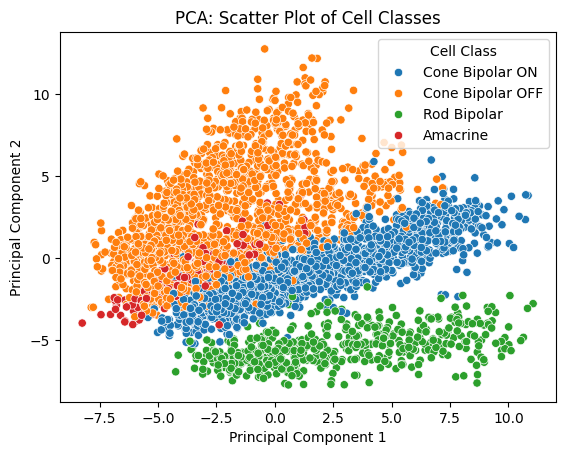

In [ ]:
#question a
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting
sns.scatterplot(x='PC1', y='PC2', hue=data_week1["CLASS"], data=pca_df)
plt.title("PCA: Scatter Plot of Cell Classes")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cell Class")
plt.show()


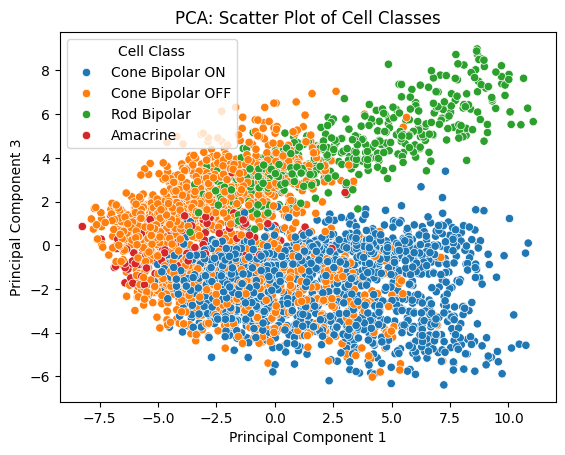

In [ ]:
#pc3 vs pc1
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting
sns.scatterplot(x='PC1', y='PC3', hue=data_week1["CLASS"], data=pca_df)
plt.title("PCA: Scatter Plot of Cell Classes")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 3")
plt.legend(title="Cell Class")
plt.show()


In [ ]:
def pca_summary(pca):
  """
  Use pca object to obtain PVE for the PCs.
  """
  stds = np.round(np.sqrt(pca.explained_variance_), 4)
  #print(len(stds))
  prop_of_var = np.round(pca.explained_variance_ratio_, 4)
  cumul_prop = np.round(pca.explained_variance_ratio_.cumsum(), 4)
  indices = ["PC_{}".format(el) for el in range(1, len(stds)+1)]
  df = pd.DataFrame({"Standard deviation": stds,
                     "Proportion of variance": prop_of_var,
                     "Cumulative Proportion": cumul_prop},
                    index=indices)
  #print("Importance of components: \n")
  return df

In [ ]:
pve_out=pca_summary(pca)
print(pve_out)
#Printing PVE for the first few and last few PCs; that of first few is of interest, for the last few PCs is usually not of interest, but is shown for the sake of illustration.

        Standard deviation  Proportion of variance  Cumulative Proportion
PC_1                3.9400                  0.0343                 0.0343
PC_2                3.5416                  0.0277                 0.0621
PC_3                2.7589                  0.0168                 0.0789
PC_4                2.4646                  0.0134                 0.0923
PC_5                2.1006                  0.0098                 0.1021
...                    ...                     ...                    ...
PC_448              0.5386                  0.0006                 0.9979
PC_449              0.5379                  0.0006                 0.9986
PC_450              0.5275                  0.0006                 0.9992
PC_451              0.4520                  0.0005                 0.9996
PC_452              0.4001                  0.0004                 1.0000

[452 rows x 3 columns]


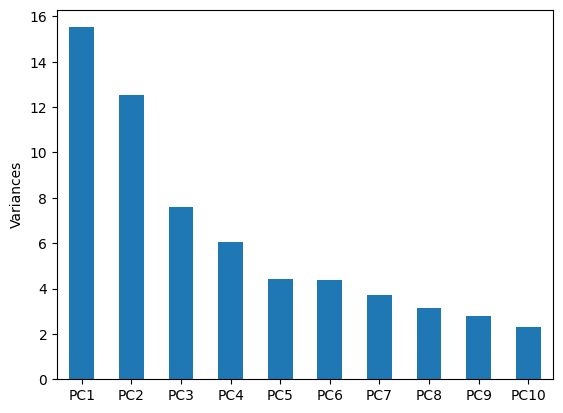

In [ ]:
pca_df.iloc[:,:10].var(axis=0, ddof=0).plot(kind='bar', rot=0)
plt.ylabel('Variances');

In [ ]:
#question b


num_top_genes = 20
# Get the top genes for PC1 and PC2
top_genes_pc1 = pca_loadings['V1'].abs().sort_values(ascending=False).head(num_top_genes).index
top_genes_pc2 = pca_loadings['V2'].abs().sort_values(ascending=False).head(num_top_genes).index

# Combine top genes from both PCs
top_genes = set(top_genes_pc1) | set(top_genes_pc2)

# Print or analyze the top genes
print("Top Genes:")
print(top_genes)


Top Genes:
{'Tgfb2', 'Prkca', 'Slitrk6', 'Sphkap', 'Pcp2', 'Lhx4', 'Aplp2', 'Isl1', 'Zfp365', 'Tmsb10', 'Gnb3', 'Mgarp', 'Fam19a3', 'Gpr179', 'Fezf2', 'Calm1', 'Nnat', 'Slc25a4', 'Otor', 'Pkm', 'Chgb', 'Qpct', 'mtCytb', 'Grik1', 'Trnp1', 'Gsg1', 'Car8', 'Gng13', 'Grm6', 'Lbh', 'App', 'Rpgrip1', 'Gnao1', 'Ttyh1', 'Trpm1', 'Lin7a'}


In [ ]:
pca_loadings['V1'].abs().sort_values(ascending=False).head(num_top_genes).index

Index(['Gng13', 'Gnao1', 'Gnb3', 'Trpm1', 'Calm1', 'Isl1', 'Aplp2', 'Pcp2',
       'Mgarp', 'Grm6', 'mtCytb', 'Gpr179', 'Ttyh1', 'Slc25a4', 'Tgfb2',
       'Qpct', 'Lin7a', 'Zfp365', 'Trnp1', 'Tmsb10'],
      dtype='object')

In [ ]:
pca_loadings['V2'].abs().sort_values(ascending=False).head(num_top_genes).index


Index(['Grik1', 'Gsg1', 'Calm1', 'Pcp2', 'Fam19a3', 'Nnat', 'Lbh', 'Trpm1',
       'Otor', 'Chgb', 'Lhx4', 'Prkca', 'Car8', 'Slitrk6', 'App', 'Qpct',
       'Rpgrip1', 'Pkm', 'Sphkap', 'Fezf2'],
      dtype='object')

In [ ]:
pca.explained_variance_

array([15.52369891, 12.54271759,  7.61155678,  6.07430732,  4.41251214,
        4.36407208,  3.70076185,  3.1414294 ,  2.77696869,  2.28909951,
        2.04995949,  1.82816963,  1.72750679,  1.67243193,  1.6565216 ,
        1.63721696,  1.62819919,  1.60030458,  1.59877499,  1.59063606,
        1.58425893,  1.57141656,  1.56512306,  1.55884753,  1.55209806,
        1.54798337,  1.53720196,  1.5331728 ,  1.52265798,  1.51523711,
        1.51342921,  1.50948131,  1.49655791,  1.49481984,  1.48856564,
        1.47759775,  1.47403528,  1.46763453,  1.46482923,  1.4593577 ,
        1.452298  ,  1.44922374,  1.4394343 ,  1.4373803 ,  1.4311513 ,
        1.42735995,  1.41843818,  1.41520705,  1.41454888,  1.40438435,
        1.39681881,  1.392497  ,  1.38866152,  1.38481254,  1.38016886,
        1.37311272,  1.3715599 ,  1.36569069,  1.36243383,  1.36011912,
        1.35378503,  1.35304153,  1.34318876,  1.33896831,  1.33587501,
        1.33007652,  1.326895  ,  1.32601147,  1.32140802,  1.31

In [ ]:
pca.explained_variance_ratio_

array([0.03433524, 0.02774192, 0.01683521, 0.01343512, 0.00975957,
       0.00965243, 0.00818533, 0.0069482 , 0.00614209, 0.00506302,
       0.00453409, 0.00404354, 0.00382089, 0.00369908, 0.00366389,
       0.00362119, 0.00360124, 0.00353955, 0.00353616, 0.00351816,
       0.00350406, 0.00347565, 0.00346173, 0.00344785, 0.00343292,
       0.00342382, 0.00339998, 0.00339106, 0.00336781, 0.00335139,
       0.0033474 , 0.00333866, 0.00331008, 0.00330624, 0.0032924 ,
       0.00326814, 0.00326026, 0.00324611, 0.0032399 , 0.0032278 ,
       0.00321219, 0.00320539, 0.00318373, 0.00317919, 0.00316541,
       0.00315703, 0.00313729, 0.00313015, 0.00312869, 0.00310621,
       0.00308948, 0.00307992, 0.00307144, 0.00306292, 0.00305265,
       0.00303704, 0.00303361, 0.00302063, 0.00301342, 0.00300831,
       0.0029943 , 0.00299265, 0.00297086, 0.00296152, 0.00295468,
       0.00294186, 0.00293482, 0.00293287, 0.00292268, 0.0029093 ,
       0.0028998 , 0.00289215, 0.00288215, 0.00287533, 0.00287

In [ ]:
# Assuming pca is your fitted PCA object
# pca = PCA(random_state=42)
# pca.fit(X_scaled)

# Get the explained variance ratios and component names
explained_variance_ratios = pca.explained_variance_ratio_
component_names = [f"PC{i+1}" for i in range(len(explained_variance_ratios))]

# Find the index of the component that explains the maximum variance
max_variance_index = np.argmax(explained_variance_ratios)

# Get the name and amount of variance of the max variance component
max_variance_component_name = component_names[max_variance_index]
max_variance_amount = explained_variance_ratios[max_variance_index]

print(f"Component {max_variance_component_name} explains the maximum variance with {max_variance_amount:.4f} variance.")


Component PC1 explains the maximum variance with 0.0343 variance.


In [ ]:
def variance_plots(pca, nr_pcs):
  """
  Plots the proportion variance explained (PVE) as well as the cumulative PVE.
  pca is pca object obtained from PCA()
  nr_pcs is the number of PCs to be used
  """
  fig , (ax1,ax2) = plt.subplots(1,2, figsize=(9,5))

  # Left plot
  ax1.plot(list(range(1, nr_pcs+1)), pca.explained_variance_ratio_[:nr_pcs], '-o')
  ax1.set_ylabel('Proportion of Variance Explained')
  ax1.set_ylim(ymin=0.0, ymax=1.05)

  # Right plot
  ax2.plot(list(range(1, nr_pcs+1)), np.cumsum(pca.explained_variance_ratio_[:nr_pcs]), '-ro')
  ax2.set_ylabel('Cumulative Proportion of Variance Explained')
  ax2.set_ylim(ymin=0.0, ymax=1.05)

  for ax in fig.axes:
      ax.set_xlabel('Principal Component')
      ax.set_xlim(0.95, nr_pcs+0.2)

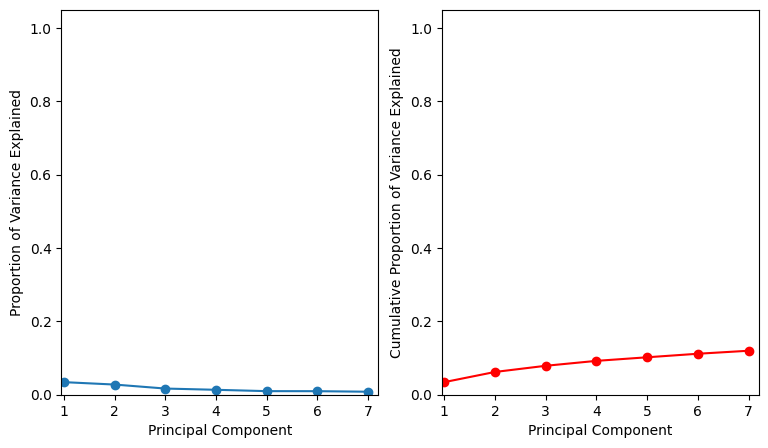

In [ ]:
variance_plots(pca,7)

In [ ]:
#keep
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Assuming data_week3 is your dataset with genes as columns
X = data_week1.drop(["CLASS"], axis=1)  # Assuming "CLASS" is the target variable, remove it for PCA
y = data_week1["CLASS"]  # Target variable

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Perform PCA
pca = PCA(random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_

# Cumulative explained variance
cumulative_explained_variance = explained_variance_ratio.cumsum()

# Number of components needed to explain a certain percentage of variance (e.g., 95%)
num_components_for_95_percent_var = (cumulative_explained_variance >= 0.95).sum() + 1
num_components_for_99_percent_var = (cumulative_explained_variance >= 0.99).sum() + 1

# Print information
print(f"Explained Variance Ratio: {explained_variance_ratio}")
print(f"Cumulative Explained Variance: {cumulative_explained_variance}")
print(f"Number of Components for 95% Variance: {num_components_for_95_percent_var}")
print(f"Number of Components for 99% Variance: {num_components_for_99_percent_var}")



Explained Variance Ratio: [0.03433524 0.02774192 0.01683521 0.01343512 0.00975957 0.00965243
 0.00818533 0.0069482  0.00614209 0.00506302 0.00453409 0.00404354
 0.00382089 0.00369908 0.00366389 0.00362119 0.00360124 0.00353955
 0.00353616 0.00351816 0.00350406 0.00347565 0.00346173 0.00344785
 0.00343292 0.00342382 0.00339998 0.00339106 0.00336781 0.00335139
 0.0033474  0.00333866 0.00331008 0.00330624 0.0032924  0.00326814
 0.00326026 0.00324611 0.0032399  0.0032278  0.00321219 0.00320539
 0.00318373 0.00317919 0.00316541 0.00315703 0.00313729 0.00313015
 0.00312869 0.00310621 0.00308948 0.00307992 0.00307144 0.00306292
 0.00305265 0.00303704 0.00303361 0.00302063 0.00301342 0.00300831
 0.0029943  0.00299265 0.00297086 0.00296152 0.00295468 0.00294186
 0.00293482 0.00293287 0.00292268 0.0029093  0.0028998  0.00289215
 0.00288215 0.00287533 0.00287029 0.00286556 0.00285643 0.00284569
 0.00282214 0.00281947 0.0028133  0.00280668 0.00279571 0.00278748
 0.00278482 0.00278061 0.00276957 0.

In [ ]:
#might be wrong
# Sort components based on their importance in explaining variance
sorted_components = pca_loadings.abs().sum(axis=1).sort_values(ascending=False).head(17)

# Get the names of the top 17 components
selected_components = sorted_components.index
print("Names of the 17 components for 99% variance:")
print(selected_components)


Names of the 17 components for 99% variance:
Index(['Cox7b', 'Rogdi', 'Zfp385b', 'Atp6v1e1', 'Lyve1', 'Strbp', 'Arl3',
       'Psip1', 'Rtn4', 'Tuba1a', 'Hmgn3', 'Syt1', 'Rps24', 'Bsg', 'Rplp1',
       'Ahi1', 'Rps9'],
      dtype='object')


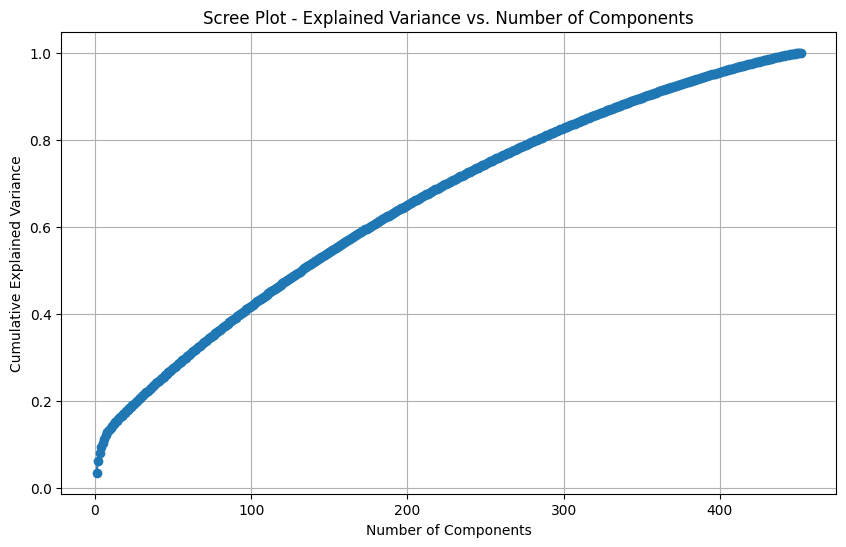

In [ ]:
import matplotlib.pyplot as plt

# Plotting the scree plot
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_explained_variance) + 1), cumulative_explained_variance, marker='o', linestyle='--')
plt.title('Scree Plot - Explained Variance vs. Number of Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.show()


# CLUSTERING

dendogram [ data_week3 ]

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


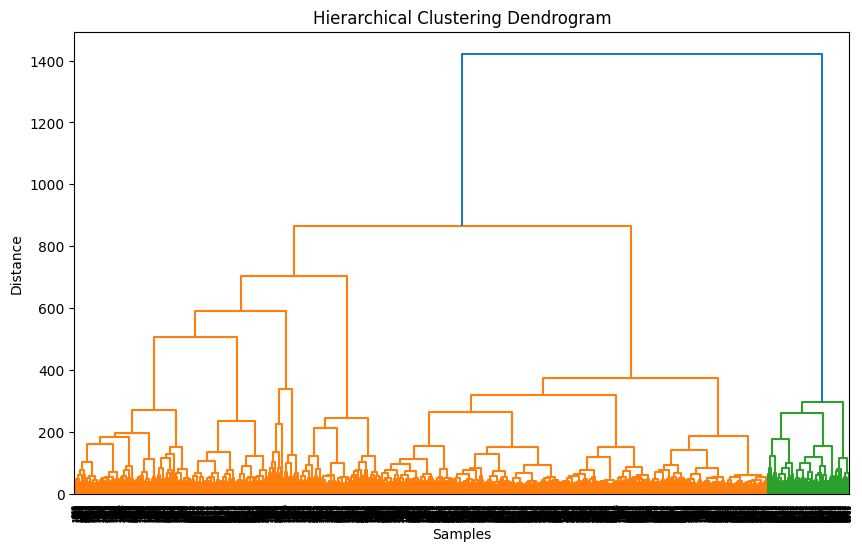

In [ ]:
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import linkage, dendrogram
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming X is your data
X= data_week3

# K-Means clustering
kmeans = KMeans(n_clusters=10, random_state=42)# desired_number_of_clusters = 10
kmeans_labels = kmeans.fit_predict(X)

# Hierarchical clustering
dendrogram_data = linkage(X, method='ward', metric='euclidean')

# Plot dendrogram
plt.figure(figsize=(10, 6))
dendrogram(dendrogram_data, orientation='top', labels=X.index, distance_sort='descending', show_leaf_counts=True)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Samples')
plt.ylabel('Distance')
plt.show()

# Compare clustering results
# You can compare kmeans_labels with hierarchical clustering results and visualize the differences


b) Can you say something about how many clusters are present in this dataset?
To determine the optimal number of clusters, you can use methods like the elbow method for k-means or analyzing the dendrogram for hierarchical clustering.

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:8

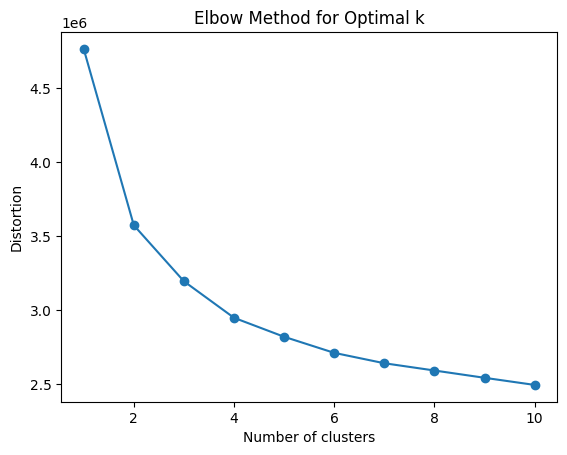

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# X is your data
X = data_week3
# Calculate distortion for a range of clusters
distortions = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X)
    distortions.append(kmeans.inertia_)

# Plot the elbow method
plt.plot(range(1, 11), distortions, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of clusters')
plt.ylabel('Distortion')
plt.show()


c) Compare cell type labels to clustering results
After clustering, you can compare the obtained clusters with known cell type labels. You can use metrics like Adjusted Rand Index (ARI) or visual inspection to assess the similarity.

In [ ]:
pca_df

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC443,PC444,PC445,PC446,PC447,PC448,PC449,PC450,PC451,PC452
0,1.809979,-1.176693,1.154901,4.263111,7.212358,-7.043940,-4.032425,0.588446,1.185198,0.196492,...,-0.462472,-0.756820,-0.148072,0.545476,0.808120,1.095832,0.007277,-0.270825,-0.506775,0.386461
1,-0.456681,8.354357,5.610428,-0.569967,-2.068058,-3.017672,-0.527557,3.059830,1.859878,-0.692429,...,0.011404,0.705780,0.689896,0.164239,0.136531,-0.073337,-0.017322,-0.142111,0.201782,0.134139
2,8.067992,2.022647,-2.787995,0.046320,0.359902,-2.611424,-1.130072,0.455603,5.897153,0.692622,...,-0.541074,0.800872,0.298388,-0.356871,-0.042493,0.086346,0.219944,-0.038898,-0.433191,0.540408
3,1.498081,4.814254,-0.479978,4.010789,-1.461298,2.262081,-4.222279,-1.128459,-0.334426,2.592167,...,-0.410638,-0.005441,-0.451706,2.163237,-0.835188,1.053946,0.120604,-0.777496,0.461942,-0.158814
4,7.122736,2.570324,-0.035781,-4.959219,-3.678160,2.893631,0.836860,1.382901,1.084666,-0.825960,...,-0.155973,0.509953,-0.028193,-0.084550,0.066186,-0.075901,0.543954,0.343663,0.480510,0.031528
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3719,-3.790940,-3.905104,-1.867869,-0.721631,-0.326656,-0.966100,0.206926,-0.377365,-1.264894,1.786192,...,0.965269,-0.192142,-0.157221,-0.036284,-0.461925,0.282380,0.242280,0.189907,-0.399306,0.294337
3720,-4.214774,-3.078015,-1.548137,-3.474504,1.035602,0.329911,0.485678,0.005188,-1.514862,0.690796,...,-0.419220,-0.090656,-0.234996,0.172650,-0.434981,-0.726404,0.394710,-0.657102,-0.012436,0.018341
3721,-3.638886,-3.846498,-0.472737,-2.304239,0.378499,-0.288065,0.367620,-0.014494,-2.178394,1.145658,...,-0.131341,-0.143543,0.417733,0.041296,-0.182862,-0.413178,0.271514,-0.220342,0.335616,0.569495
3722,-3.992286,-1.789471,-3.045839,0.784472,0.895811,1.485962,3.136485,1.100327,-2.489424,-0.063299,...,-0.404461,0.033519,-0.106150,0.181977,0.214038,-0.366594,-0.098558,0.739317,0.240095,-0.500282


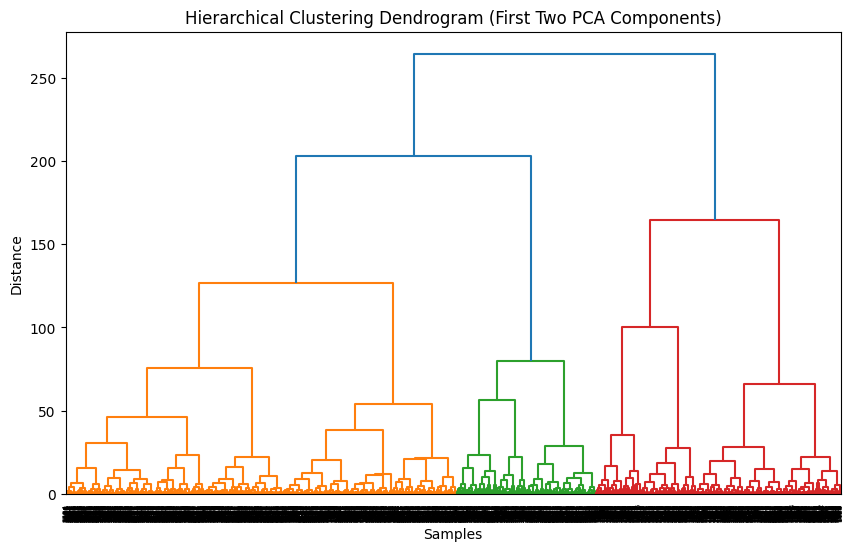

In [ ]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt


# pca_df is your DataFrame with principal components
X_pca_2d = pca_df[['PC1', 'PC2']]



# Perform hierarchical clustering on the first two principal components
dendrogram_data_pca = linkage(X_pca_2d, method='ward', metric='euclidean')

# Plot dendrogram for hierarchical clustering
plt.figure(figsize=(10, 6))
#dendrogram(dendrogram_data_pca, orientation='top', labels=pca_df.index, distance_sort='descending', show_leaf_counts=True)
dendrogram(dendrogram_data_pca, orientation='top', labels=X_pca_2d.index, distance_sort='descending', show_leaf_counts=True)

plt.title('Hierarchical Clustering Dendrogram (First Two PCA Components)')
plt.xlabel('Samples')
plt.ylabel('Distance')
plt.show()


**a**) Compare the different clustering results. Do different methods give similar results?

clustering with three methods
Linkage [complete, average, single]

In [ ]:
import scipy.cluster.hierarchy as shc
from scipy.cluster.hierarchy import fcluster, cut_tree, linkage, dendrogram

In [ ]:
hc_complete = linkage(X_scaled, method='complete')

In [ ]:
hc_avg = linkage(X_scaled, method='average')
hc_single = linkage(X_scaled, method='single')

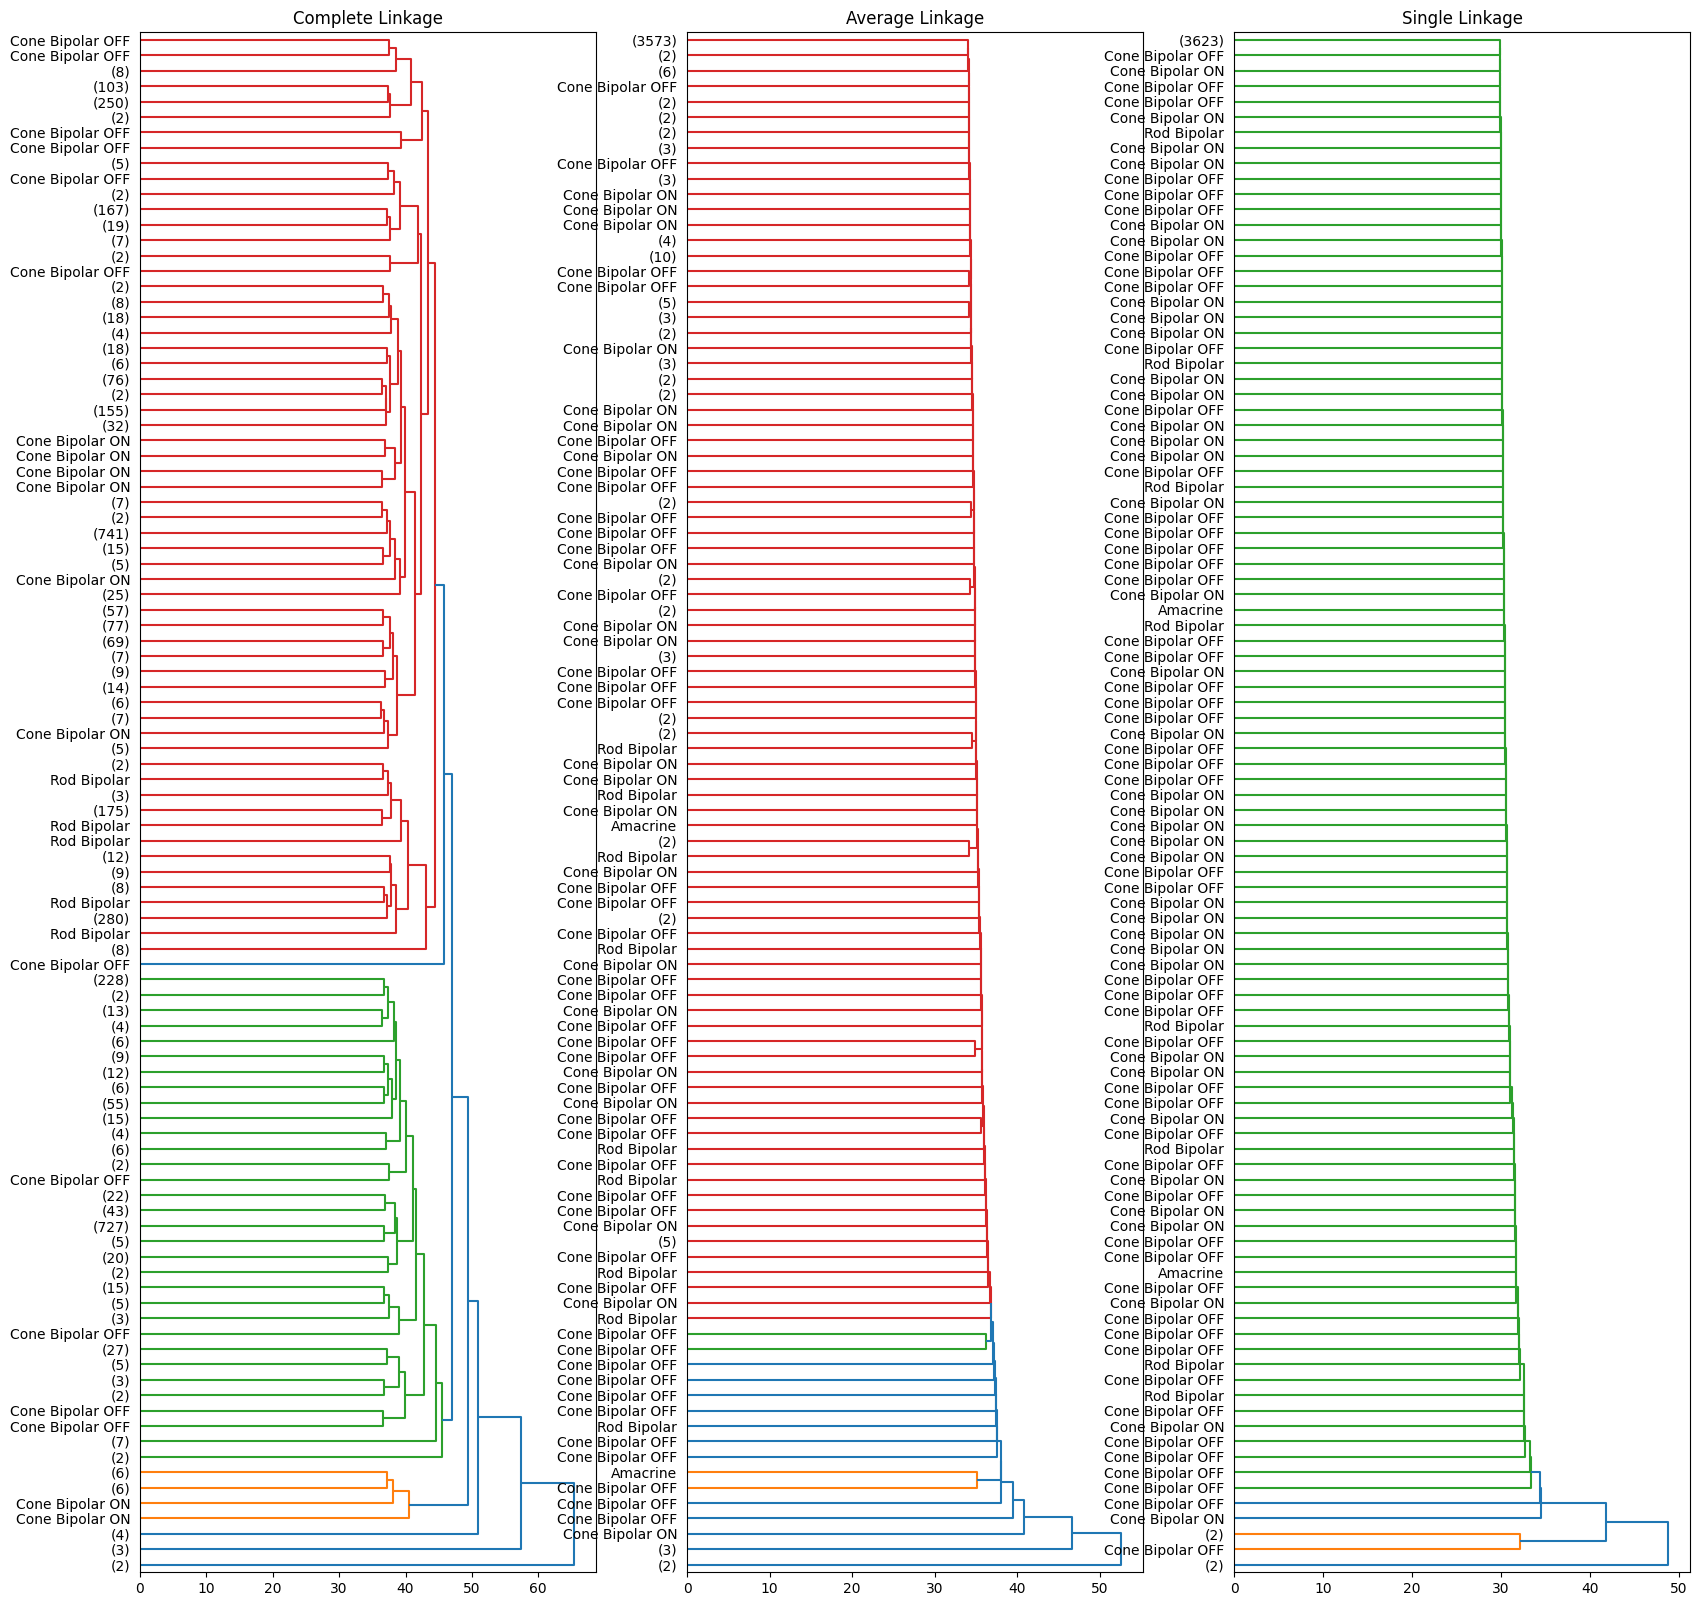

In [ ]:
fig, (ax1,ax2,ax3) = plt.subplots(1,3, figsize=(20,20))

for linkage, cluster, ax in zip([hc_complete, hc_avg, hc_single],
                                ['c1','c2','c3'],
                                [ax1,ax2,ax3]):
    cluster = dendrogram(linkage, orientation='right', leaf_font_size=10, ax=ax,labels=data["CLASS"].tolist(), truncate_mode='lastp',p=100)

ax1.set_title('Complete Linkage')
ax2.set_title('Average Linkage')
ax3.set_title('Single Linkage');

In [ ]:
hc_clusters = cut_tree(hc_complete, 4).ravel()
pd.crosstab(data.CLASS, hc_clusters).T

CLASS,Amacrine,Cone Bipolar OFF,Cone Bipolar ON,Rod Bipolar
col_0,,,,
0,125,1656,1434,500
1,4,0,0,0
2,0,0,2,0
3,0,2,1,0


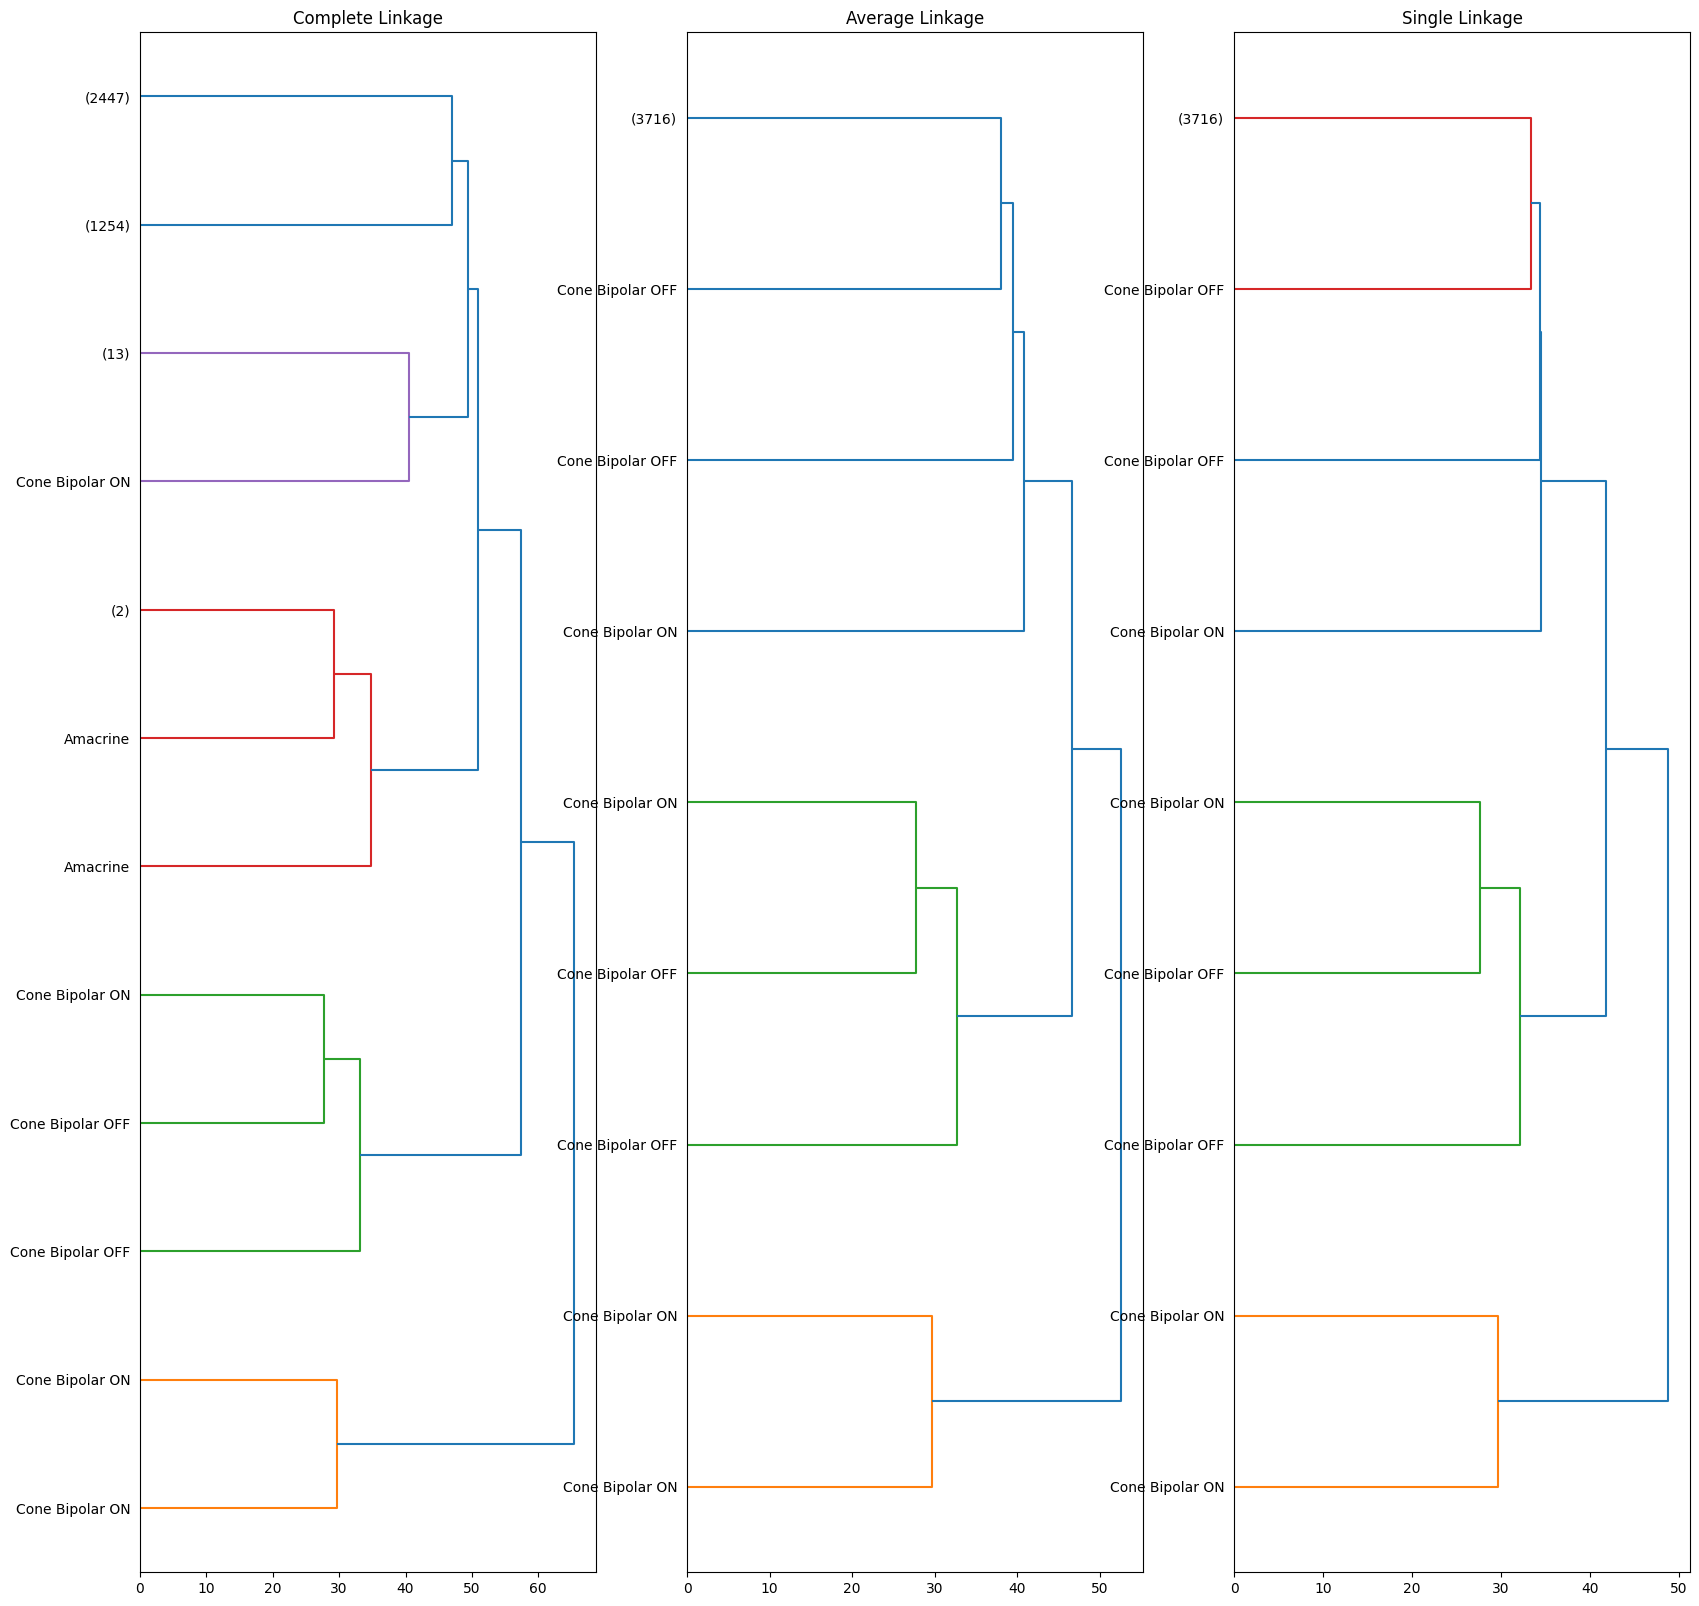

In [ ]:
fig, (ax1,ax2,ax3) = plt.subplots(1,3, figsize=(20,20))

for linkage, cluster, ax in zip([hc_complete, hc_avg, hc_single],
                                ['c1','c2','c3'],
                                [ax1,ax2,ax3]):
    cluster = dendrogram(linkage, orientation='right', leaf_font_size=10, ax=ax,labels=data["CLASS"].tolist(), truncate_mode='level',p=4)

ax1.set_title('Complete Linkage')
ax2.set_title('Average Linkage')
ax3.set_title('Single Linkage');

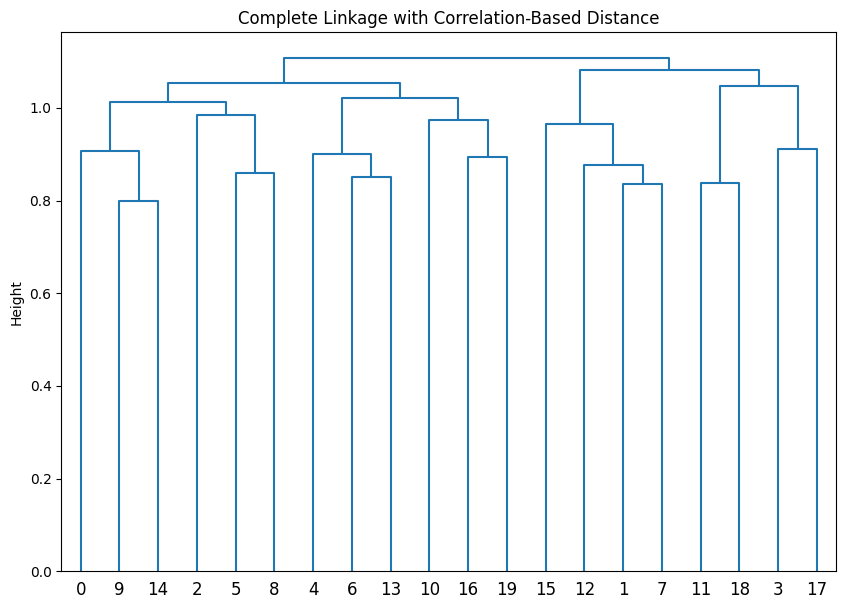

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage

hc_complete_corr_based= linkage(X_scaled[:20], method='complete', metric='correlation')

# dendrogram
plt.figure(figsize=(10, 7))
plt.title("Complete Linkage with Correlation-Based Distance")
plt.ylabel("Height")
dend = dendrogram(hc_complete_corr_based)

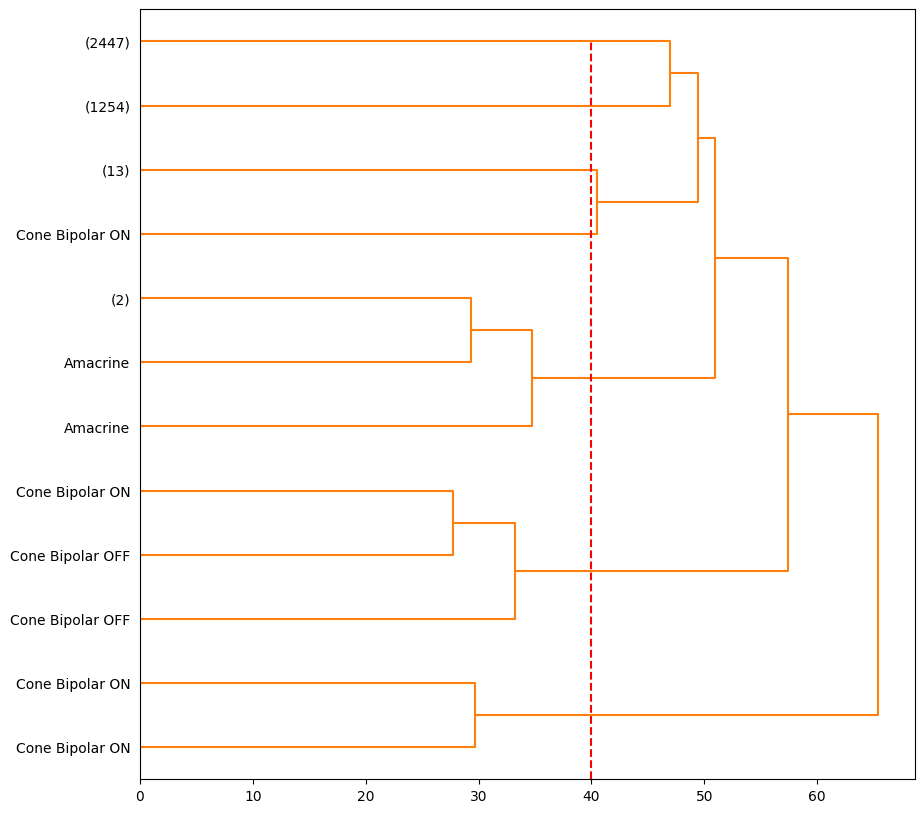

In [ ]:
plt.figure(figsize=(10,10))
cut = dendrogram(hc_complete, orientation='right', color_threshold=140, leaf_font_size=10,labels=data["CLASS"].tolist(),truncate_mode='level',p=4)
plt.vlines(40,0,plt.gca().yaxis.get_data_interval()[1], colors='r', linestyles='dashed');

kkkkkkkkk

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters = 4 , random_state = 0)
kmeans.fit(pca_df)

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


KMeans(n_clusters=4, random_state=0)

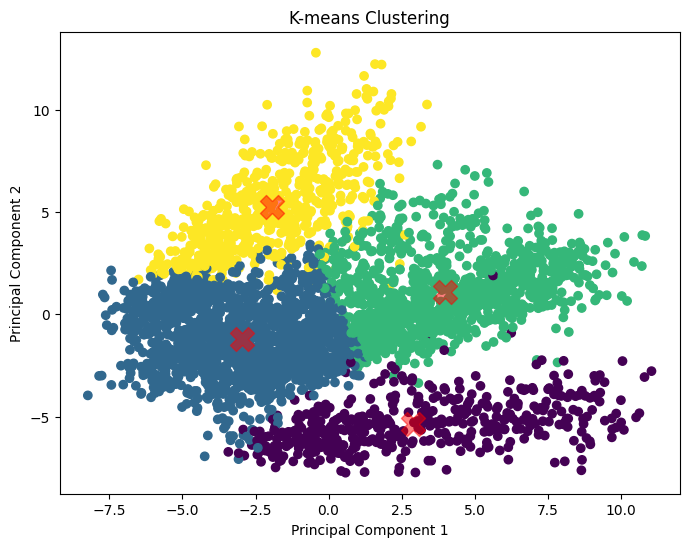

In [ ]:
import matplotlib.pyplot as plt
lables = kmeans.labels_

centroids = kmeans.cluster_centers_

plt.figure(figsize=(8,6))
plt.scatter(pca_df['PC1'], pca_df['PC2'], c= lables, cmap = 'viridis')
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s = 300 , alpha =0.5, marker ='X')
plt.title("K-means Clustering")
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

In [ ]:
import pandas as pd
from sklearn.metrics import confusion_matrix, adjusted_rand_score

# Assuming 'data' is your DataFrame, 'labels' contains your k-means cluster assignments
data['Cluster_Labels'] = lables

# Contingency Table for Cell Types
print("Contingency Table for Cell Types:")
contingency_table_types = pd.crosstab(data['CELLTYPE'], data['Cluster_Labels'])
print(contingency_table_types)

# Contingency Table for Classes
print("\nContingency Table for Classes:")
contingency_table_classes = pd.crosstab(data['CLASS'], data['Cluster_Labels'])
print(contingency_table_classes)

# Calculate Adjusted Rand Index for Cell Types
ari_types = adjusted_rand_score(data['CELLTYPE'], data['Cluster_Labels'])
print("\nAdjusted Rand Index for Cell Types:", ari_types)

# Calculate Adjusted Rand Index for Classes
ari_classes = adjusted_rand_score(data['CLASS'], data['Cluster_Labels'])
print("Adjusted Rand Index for Classes:", ari_classes)

Contingency Table for Cell Types:
Cluster_Labels    0    1    2    3
CELLTYPE                          
Amacrine_1        0   61    3    0
Amacrine_2        0   59    4    2
BC2               0  189  137    0
BC3A              1  268  104    8
BC3B              2  217    2  459
BC4               1  114    1  155
BC6               4  304  416    0
BC7               2  290  421    0
Rod BC          475   25    0    0

Contingency Table for Classes:
Cluster_Labels      0    1    2    3
CLASS                               
Amacrine            0  120    7    2
Cone Bipolar OFF    4  788  244  622
Cone Bipolar ON     6  594  837    0
Rod Bipolar       475   25    0    0

Adjusted Rand Index for Cell Types: 0.22911705851011643
Adjusted Rand Index for Classes: 0.27269476825120276


cell type

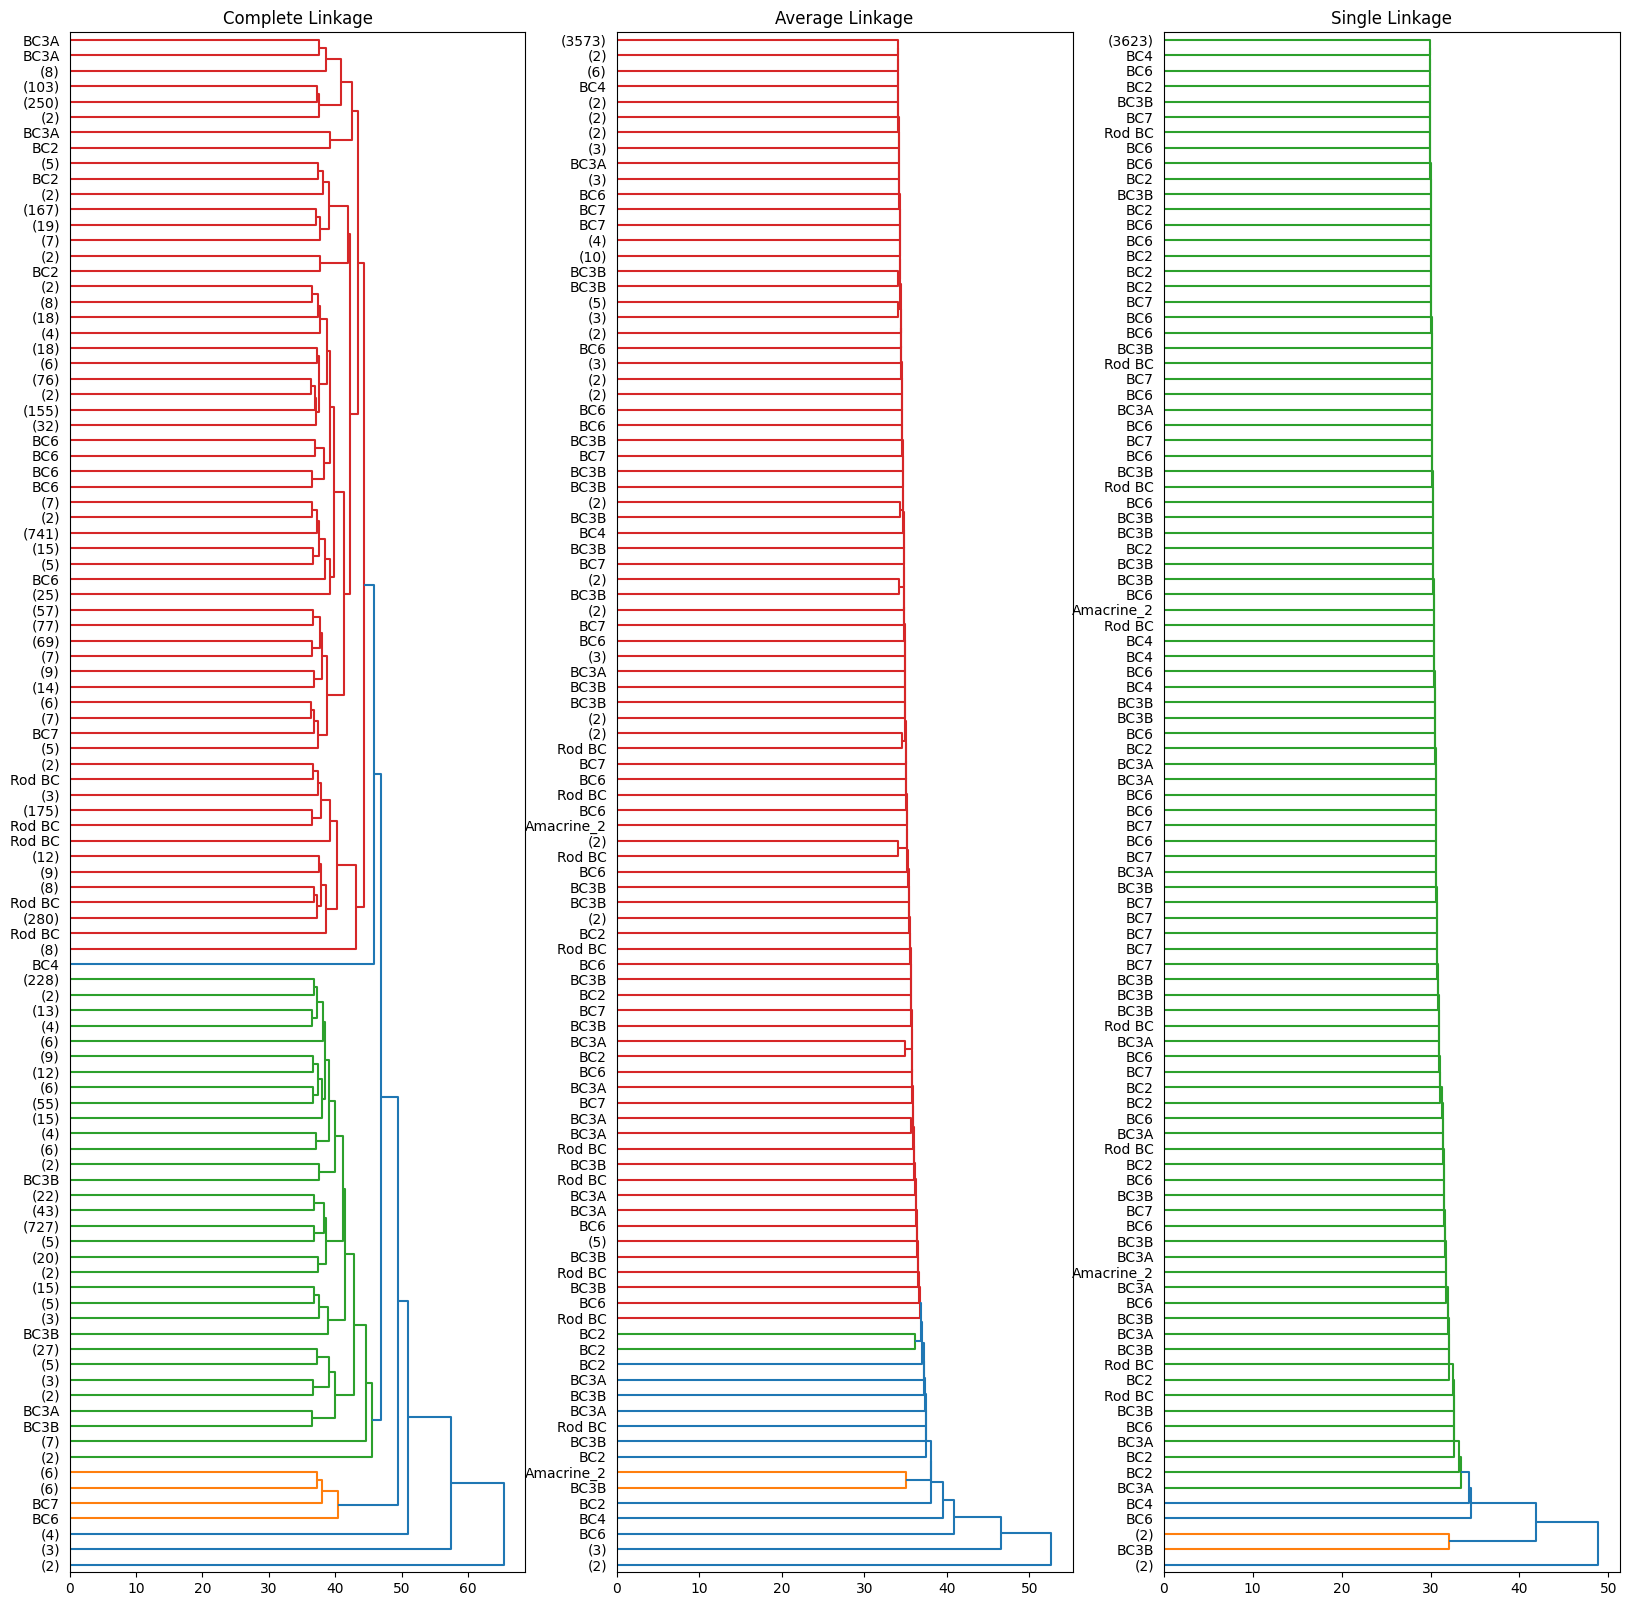

In [ ]:
fig, (ax1,ax2,ax3) = plt.subplots(1,3, figsize=(20,20))

for linkage, cluster, ax in zip([hc_complete, hc_avg, hc_single],
                                ['c1','c2','c3'],
                                [ax1,ax2,ax3]):
    cluster = dendrogram(linkage, orientation='right', leaf_font_size=10, ax=ax,labels=data["CELLTYPE"].tolist(), truncate_mode='lastp',p=100)

ax1.set_title('Complete Linkage')
ax2.set_title('Average Linkage')
ax3.set_title('Single Linkage');

In [ ]:
hc_clusters = cut_tree(hc_complete, 9).ravel()
pd.crosstab(data.CLASS, hc_clusters).T